In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import random
from matplotlib.image import imread
from PIL import Image
import cv2
import shutil
import numpy as np
from tqdm import tqdm
from collections import Counter
import albumentations as A
from albumentations.pytorch import ToTensorV2
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,confusion_matrix
from sklearn.utils import class_weight
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight


import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout,BatchNormalization,GlobalAveragePooling2D

from tensorflow.keras.optimizers import Adamax, Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator,load_img, img_to_array
from tensorflow.keras.callbacks import EarlyStopping,ModelCheckpoint
from tensorflow.keras.models import load_model

from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

import warnings
warnings.filterwarnings('ignore')

2026-01-26 12:40:39.500975: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1769431239.830166      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1769431239.930926      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1769431240.767741      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769431240.767795      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769431240.767798      55 computation_placer.cc:177] computation placer alr

In [2]:
landmarks_path= Path("/kaggle/input/final-landmark-dataset/Final Dataset 4 JPG")
classes = os.listdir(landmarks_path)
print(classes)

['The Small Aten Temple', 'Qasr Qarun', 'Pyramid of Meidum', 'Temple of Kom Ombo', 'Temple of Luxor', 'Temple of Isis in Philae', 'Temple of Hathor in Philae', 'Pyramid of Senefru - Bent Pyramid of Senefru', 'Temple of Dakka', 'Temple of Hathor in Dendera', 'Temple of Maharraqa', 'Pyramids of Giza', 'Black Pyramid of Amenemhat III', 'Temple of Horus at Edfu', 'Famine Stele', 'Al Qurn', 'Small Temple of Hathor and Nefertari at Abu Simbel', 'Sphinx', 'Temple of Kalabsha', 'Ptolemaic Temple of Hathor in Deir el Medina', 'Kiosk of Trajan in Philae', 'Temple of Khonsu in Karnak', 'Temple of Karnak', 'Colossoi of Memnon', 'Pyramid of Seila', 'Temple of Hatshepsut in Deir El Bahari', 'Temple of Habu', 'Osireion', 'Ramessum', 'Pyramid of Saqqara - Pyramid of Djoser', 'Temple of Amada', 'Tomb of Horemheb in Saqqara', 'Pyramid of Sahure', 'Sphinx of Memphis', 'Temple of Seti I in Abydos', 'The Roman Mammisi in Dendera', 'Temple of Wadi es-Sebua - Temple of Ramesses II', 'Tomb of Petosiris', 'Tem

In [3]:
len(classes)

52

In [4]:
pharoas_path= Path("/kaggle/input/final-pharaohs-dataset/Final Dataset 2")
classes = os.listdir(pharoas_path)
print(classes)

['Seti I', 'Ramesses II and Goddess', 'Amenhotep III and God Re-Horakhty', 'Merenptah and Goddess Mut', 'Khasekhem', 'Ahmose I', 'Ptolemy II Philadelphus', 'Amenhotep II', 'Sobekhotep IV', 'Isis (Goddess) with her child', 'Amun-Ra (God)', 'Arsinoe III (Queen, daughter of Ptolemy I and wife of Ptolemy II)', 'Neferkare Shabaka', 'Amun (God)', 'Ramesses II and God Ptah and Goddess Sekhment', 'Senwosret III', 'Psusennes I', 'Senwosret I', 'Ptolemy I Soter', 'Khafre', 'Khufu', 'Nofret (Queen, possibly Nofret II, wife of Senusret II)', 'Rameses II and Hauron', 'Raneferef', 'Anubis (God)', 'Ramesses II and Goddess Anath', 'Menkaure and his wife (likely Queen Khamerernebty II)', 'Hormheb', 'Ramesses II and Goddesses Isis and Hathor', 'Teti', 'Thutmose IV and his mother Tiaa', 'Ptolemy III Euergetes', 'Senwosret IV', 'Tutankhamun and consort Ankhsenamun', 'Osiris (God)', 'Serapis (God)', 'Menkuare', 'Ramesses III and Gods Horus and Seth', 'Ramesses II and God Ptah and a Goddess', 'Achoris', 'Sn

In [5]:
len(classes)

96

## Utility Functions

In [6]:
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp"}

def list_subdirs(path: Path):
    return sorted([p for p in path.iterdir() if p.is_dir()])

def count_images_recursive(path: Path):
    return sum(1 for p in path.rglob("*") if p.suffix.lower() in IMG_EXTS)

def count_images_in_dir(path: Path):
    return sum(1 for p in path.iterdir() if p.suffix.lower() in IMG_EXTS)

In [7]:
def make_df(path: Path):
    rows = []

    for class_dir in list_subdirs(path):
        name = os.path.basename(class_dir)
        for p in class_dir.iterdir():
            if p.suffix.lower() in IMG_EXTS:
                rows.append({"label": str(name)  , "path": str(p)})

    df = pd.DataFrame(rows, columns=["label", "path"])
    return df

df1=make_df(landmarks_path)
df2=make_df(pharoas_path)
df1.sample(10)


,label,path
2519,Pyramids of Giza,/kaggle/input/final-landmark-dataset/Final Dat...
709,Kiosk of Trajan in Philae,/kaggle/input/final-landmark-dataset/Final Dat...
4062,Temple of Hatshepsut in Deir El Bahari,/kaggle/input/final-landmark-dataset/Final Dat...
3455,Sphinx,/kaggle/input/final-landmark-dataset/Final Dat...
1427,Pyramid of Saqqara - Pyramid of Djoser,/kaggle/input/final-landmark-dataset/Final Dat...
2098,Pyramids of Giza,/kaggle/input/final-landmark-dataset/Final Dat...
5812,The Great Temple of Ramesses II at Abu Simbel,/kaggle/input/final-landmark-dataset/Final Dat...
4760,Temple of Kalabsha,/kaggle/input/final-landmark-dataset/Final Dat...
9,Al Qurn,/kaggle/input/final-landmark-dataset/Final Dat...
4657,Temple of Isis in Philae,/kaggle/input/final-landmark-dataset/Final Dat...


In [8]:
df2.sample(10)

,label,path
564,Amasis II,/kaggle/input/final-pharaohs-dataset/Final Dat...
8399,Senwosret III,/kaggle/input/final-pharaohs-dataset/Final Dat...
10587,Tutankhamun,/kaggle/input/final-pharaohs-dataset/Final Dat...
4089,Menkuare,/kaggle/input/final-pharaohs-dataset/Final Dat...
7097,Ramesses II and God Ptah and Goddess Sekhment,/kaggle/input/final-pharaohs-dataset/Final Dat...
1760,Amun and Mut (God and Goddess),/kaggle/input/final-pharaohs-dataset/Final Dat...
2332,Djoser,/kaggle/input/final-pharaohs-dataset/Final Dat...
7381,Ramesses II and Goddesses Isis and Hathor,/kaggle/input/final-pharaohs-dataset/Final Dat...
10554,Tutankhamun,/kaggle/input/final-pharaohs-dataset/Final Dat...
321,Akhenaton,/kaggle/input/final-pharaohs-dataset/Final Dat...


In [9]:
print("Dataframe shape:", df1.shape)
print("Dataframe shape:", df2.shape)

Dataframe shape: (6000, 2)
Dataframe shape: (11022, 2)


In [10]:
df1_labeled = df1.copy()
df1_labeled["label"] = "landmarks"
df2_labeled = df2.copy()
df2_labeled["label"] = "pharaohs"

df = pd.concat([df1_labeled, df2_labeled], ignore_index=True)
df.shape

(17022, 2)

## Data Preprocessing

label
pharaohs     11022
landmarks     6000
Name: count, dtype: int64

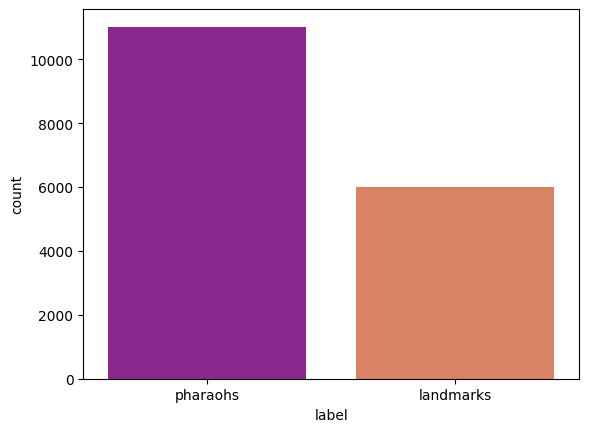

In [11]:
sns.countplot(data=df,x='label',palette='plasma',order=df['label'].value_counts().index )
df['label'].value_counts()

In [12]:
def show(title, img):
    plt.imshow(img)
    plt.title(title)
    plt.axis("off")
    plt.show()

def load_bgr(path):
    img_bgr = cv2.imread(path)
    if img_bgr is None:
        raise ValueError(f"Could not read {path}")
    return img_bgr

def bgr_to_rgb(img_bgr):
    return cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

In [13]:
image_size = 256
def resize(image, size=image_size):
  return cv2.resize(image,(size,size), interpolation=cv2.INTER_AREA)

In [14]:
train_aug = A.Compose([
    A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=15, val_shift_limit=10, p=0.2),
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=15, border_mode=cv2.BORDER_REPLICATE, p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.15, rotate_limit=15, border_mode=cv2.BORDER_REPLICATE, p=0.6),
    A.RandomScale(scale_limit=(0.1,0.3))
])

def apply_augmentation(image):
    return train_aug(image=image)["image"]

In [15]:
def normalize(image):
  return image/255.0

In [16]:
sample_row = df.iloc[9803]
sample_path = sample_row["path"]
sample_label = sample_row["label"]

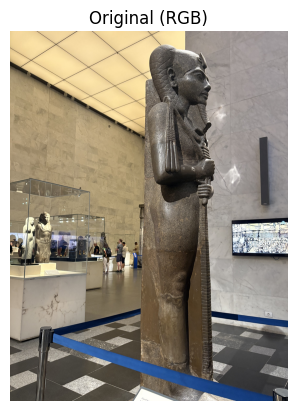

Original shape: (5712, 4284, 3) dtype: uint8


In [17]:
image_BGR = load_bgr(sample_path)
image_RGB = bgr_to_rgb(image_BGR)

show("Original (RGB)", image_RGB)
print("Original shape:", image_RGB.shape, "dtype:", image_RGB.dtype)

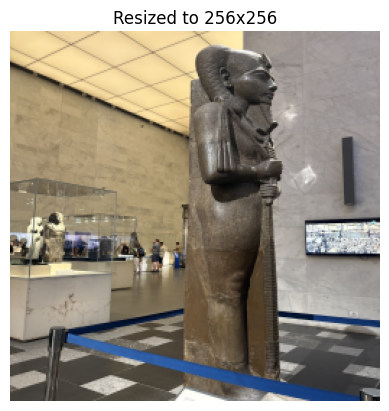

Resized shape: (256, 256, 3)


In [18]:
image_resized= resize(image_RGB,image_size)
show(f"Resized to {image_size}x{image_size}", image_resized)
print("Resized shape:", image_resized.shape)

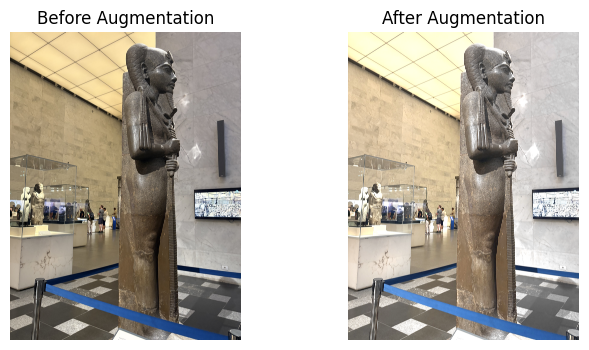

In [19]:
image_augmented = apply_augmentation(image_RGB)

plt.figure(figsize=(8,4))
plt.subplot(1,2,1); plt.imshow(image_RGB); plt.title("Before Augmentation"); plt.axis("off")
plt.subplot(1,2,2); plt.imshow(image_augmented); plt.title("After Augmentation");  plt.axis("off")
plt.show()

In [20]:
def preprocess_image(path, size=image_size, augment=False):
    image_BGR = load_bgr(path)
    image_RGB = bgr_to_rgb(image_BGR)
    image_resized = resize(image_RGB, size)

    if augment:
        image_processed = apply_augmentation(image_resized)
    else:
        image_processed = image_resized

    #image_normalized = normalize(image_processed)
    return image_processed


In [21]:
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

class TFDataset:
    def __init__(self, df, augment=False, batch_size=BATCH_SIZE, shuffle=True, image_size=image_size):
        self.df = df.reset_index(drop=True)
        self.augment = augment
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.image_size = image_size if isinstance(image_size, int) else image_size[0]
        self.dataset = self._build_dataset()

    def _load_and_preprocess(self, path, label):
        def _py_preprocess(path_str):
            path_str = path_str.decode("utf-8")
            img = preprocess_image(
                path_str,
                size=self.image_size,
                augment=self.augment
            )
            return img.astype("float32")

        img = tf.numpy_function(_py_preprocess, [path], tf.float32)
        img.set_shape((self.image_size, self.image_size, 3))
        return img, label

    def _build_dataset(self):
        paths = self.df["path"].values
        labels = self.df["label"].values.astype("float32")

        ds = tf.data.Dataset.from_tensor_slices((paths, labels))

        if self.shuffle:
            ds = ds.shuffle(buffer_size=len(self.df), reshuffle_each_iteration=True)

        ds = ds.map(self._load_and_preprocess, num_parallel_calls=AUTOTUNE)
        ds = ds.batch(self.batch_size)
        ds = ds.prefetch(AUTOTUNE)
        return ds

    def __iter__(self):
        return iter(self.dataset)

    def __len__(self):
        return int(np.ceil(len(self.df) / self.batch_size))

## Model

### Data Split

In [22]:
df.shape[0]

17022

In [23]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["label"],
    random_state=42
)

valid_df, test_df = train_test_split(
    temp_df,
    test_size=0.3,
    stratify=temp_df["label"],
    random_state=42
)

In [24]:
train_df['label'].value_counts()

label
pharaohs     8817
landmarks    4800
Name: count, dtype: int64

In [ ]:
print("Train size:", train_df.shape[0])
print("Test size:", test_df['label'].shape[0])
print("Valid size:", valid_df['label'].shape[0])

Train size: 13617
Test size: 1022
Valid size: 2383


In [26]:
train_df

,label,path
12586,pharaohs,/kaggle/input/final-pharaohs-dataset/Final Dat...
3379,landmarks,/kaggle/input/final-landmark-dataset/Final Dat...
8367,pharaohs,/kaggle/input/final-pharaohs-dataset/Final Dat...
14762,pharaohs,/kaggle/input/final-pharaohs-dataset/Final Dat...
14892,pharaohs,/kaggle/input/final-pharaohs-dataset/Final Dat...
...,...,...
8549,pharaohs,/kaggle/input/final-pharaohs-dataset/Final Dat...
2662,landmarks,/kaggle/input/final-landmark-dataset/Final Dat...
11804,pharaohs,/kaggle/input/final-pharaohs-dataset/Final Dat...
15393,pharaohs,/kaggle/input/final-pharaohs-dataset/Final Dat...


In [28]:
import os
import cv2
import shutil
from tqdm import tqdm
import numpy as np

def generate_augmented_dataset_exact(train_df, train_aug, output_dir):
    if os.path.exists(output_dir):
        print(f"⚠️ Removing old folder: {output_dir}")
        shutil.rmtree(output_dir)
    os.makedirs(output_dir, exist_ok=True)

    for label, group in tqdm(train_df.groupby("label")):
        class_dir = os.path.join(output_dir, str(label).replace(" ", "_"))
        os.makedirs(class_dir, exist_ok=True)

        n_original = len(group)
        counter = 0
        saved_originals = 0
        saved_augmented = 0

        for _, row in group.iterrows():
            img = cv2.imread(row["path"])
            if img is None:
                print("⚠️ Missing file:", row["path"])
                continue
            cv2.imwrite(os.path.join(class_dir, f"{counter}_orig.jpg"), img)
            counter += 1
            saved_originals += 1

        if label == "pharaohs":
            idx_to_augment = np.random.choice(group.index, size=n_original // 2, replace=False)
            for idx in idx_to_augment:
                img = cv2.imread(group.loc[idx]["path"])
                if img is None:
                    continue
                aug_img = train_aug(image=img)["image"]
                cv2.imwrite(os.path.join(class_dir, f"{counter}_aug.jpg"), aug_img)
                counter += 1
                saved_augmented += 1

        elif label == "landmarks":
            idx_all = list(group.index)
            idx_double = np.random.choice(idx_all, size=3200, replace=False)
            idx_single = list(set(idx_all) - set(idx_double))

            for idx in idx_double:
                img = cv2.imread(group.loc[idx]["path"])
                if img is None:
                    continue
                for _ in range(2):
                    aug_img = train_aug(image=img)["image"]
                    cv2.imwrite(os.path.join(class_dir, f"{counter}_aug.jpg"), aug_img)
                    counter += 1
                    saved_augmented += 1

            for idx in idx_single:
                img = cv2.imread(group.loc[idx]["path"])
                if img is None:
                    continue
                aug_img = train_aug(image=img)["image"]
                cv2.imwrite(os.path.join(class_dir, f"{counter}_aug.jpg"), aug_img)
                counter += 1
                saved_augmented += 1

        print(
            f"Class: {label} | Original: {saved_originals} | "
            f"Augmented added: {saved_augmented} | Total saved: {counter}"
        )

generate_augmented_dataset_exact(train_df, train_aug, output_dir=r"C:\Uni\4th Year\GP\Implementation\Recognition\Binary Classifier\Augmented Train")

  0%|          | 0/2 [00:04<?, ?it/s]


KeyboardInterrupt: 

In [27]:
augmented_data = []
base_dir = Path("/kaggle/input/binary-augmented-dataset/Augmented Train")


for class_name in os.listdir(base_dir):
    class_dir = os.path.join(base_dir, class_name)
    if not os.path.isdir(class_dir):
        continue
    for fname in os.listdir(class_dir):
        path = os.path.join(class_dir, fname)
        augmented_data.append({"path": path, "label": class_name.replace("_", " ")})

aug_df = pd.DataFrame(augmented_data)
aug_df.shape

(26025, 2)

In [28]:
aug_df.sample(10)

,path,label
1450,/kaggle/input/binary-augmented-dataset/Augment...,pharaohs
12755,/kaggle/input/binary-augmented-dataset/Augment...,pharaohs
7597,/kaggle/input/binary-augmented-dataset/Augment...,pharaohs
9362,/kaggle/input/binary-augmented-dataset/Augment...,pharaohs
8266,/kaggle/input/binary-augmented-dataset/Augment...,pharaohs
1611,/kaggle/input/binary-augmented-dataset/Augment...,pharaohs
24517,/kaggle/input/binary-augmented-dataset/Augment...,landmarks
19621,/kaggle/input/binary-augmented-dataset/Augment...,landmarks
9567,/kaggle/input/binary-augmented-dataset/Augment...,pharaohs
19894,/kaggle/input/binary-augmented-dataset/Augment...,landmarks


### Label Encoding

In [29]:
encoder = LabelEncoder()

aug_df['label'] = encoder.fit_transform(aug_df['label'])

test_df['label'] = encoder.transform(test_df['label'])
valid_df['label'] = encoder.transform(valid_df['label'])


In [30]:
counts = aug_df['label'].value_counts()
counts.index = encoder.inverse_transform(counts.index.astype(int))

counts

pharaohs     13225
landmarks    12800
Name: count, dtype: int64

### Class Weights

In [31]:
aug_df['label'].values

array([1, 1, 1, ..., 0, 0, 0])

In [32]:
y = aug_df['label']

classes = np.unique(y)
class_weights_array = class_weight.compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y
)

class_weights = dict(zip(classes, class_weights_array))

print(class_weights)

{np.int64(0): np.float64(1.0166015625), np.int64(1): np.float64(0.9839319470699432)}


In [33]:
train_data = TFDataset(
    aug_df,
    augment=False,
    batch_size=BATCH_SIZE,
    shuffle=True,
    image_size=256)

val_data = TFDataset(
    valid_df,
    augment=False,
    batch_size=BATCH_SIZE,
    shuffle=False,
    image_size=256
)

I0000 00:00:1769431262.461263      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [34]:
print("Number of samples:", len(train_data.df))
print("Number of batches:", len(train_data))

Number of samples: 26025
Number of batches: 814


### Model Building and Training

In [35]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

base_model=MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(256, 256, 3)
)

base_model.trainable = False

inputs = tf.keras.Input(shape=(256, 256, 3))

x = tf.keras.applications.mobilenet_v2.preprocess_input(inputs)
x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(512, activation="relu")(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.5)(x)

outputs = layers.Dense(1, activation="sigmoid")(x)

model = models.Model(inputs, outputs)
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 8, 8, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,045,441 (11.62 MB)

 Trainable params: 787,457 (3.00 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [36]:
model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [37]:
history = model.fit(
    train_data.dataset,
    validation_data=val_data.dataset,
    epochs=10,
    callbacks=[EarlyStopping(monitor='val_loss',mode='min',patience=5,restore_best_weights=True)],
    class_weight=class_weights
)

Epoch 1/10


I0000 00:00:1769431272.706747     126 service.cc:152] XLA service 0x7fe8ec111a90 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1769431272.706804     126 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1769431275.073337     126 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1769431285.015339     126 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


814/814 ━━━━━━━━━━━━━━━━━━━━ 762s 912ms/step - accuracy: 0.9590 - loss: 0.1021 - val_accuracy: 0.9937 - val_loss: 0.0140
Epoch 2/10
814/814 ━━━━━━━━━━━━━━━━━━━━ 723s 888ms/step - accuracy: 0.9968 - loss: 0.0116 - val_accuracy: 0.9983 - val_loss: 0.0076
Epoch 3/10
814/814 ━━━━━━━━━━━━━━━━━━━━ 721s 886ms/step - accuracy: 0.9977 - loss: 0.0071 - val_accuracy: 0.9987 - val_loss: 0.0064
Epoch 4/10
814/814 ━━━━━━━━━━━━━━━━━━━━ 724s 889ms/step - accuracy: 0.9987 - loss: 0.0041 - val_accuracy: 0.9987 - val_loss: 0.0068
Epoch 5/10
814/814 ━━━━━━━━━━━━━━━━━━━━ 782s 960ms/step - accuracy: 0.9991 - loss: 0.0029 - val_accuracy: 0.9983 - val_loss: 0.0072
Epoch 6/10
814/814 ━━━━━━━━━━━━━━━━━━━━ 786s 966ms/step - accuracy: 0.9993 - loss: 0.0020 - val_accuracy: 0.9987 - val_loss: 0.0063
Epoch 7/10
814/814 ━━━━━━━━━━━━━━━━━━━━ 732s 899ms/step - accuracy: 0.9995 - loss: 0.0019 - val_accuracy: 0.9987 - val_loss: 0.0048
Epoch 8/10
814/814 ━━━━━━━━━━━━━━━━━━━━ 729s 895ms/step - accuracy: 0.9997 - loss: 0.00

### Model Evaluation

In [38]:
losses=pd.DataFrame(history.history)

Text(0.5, 1.0, 'Model Accuracy during Training')

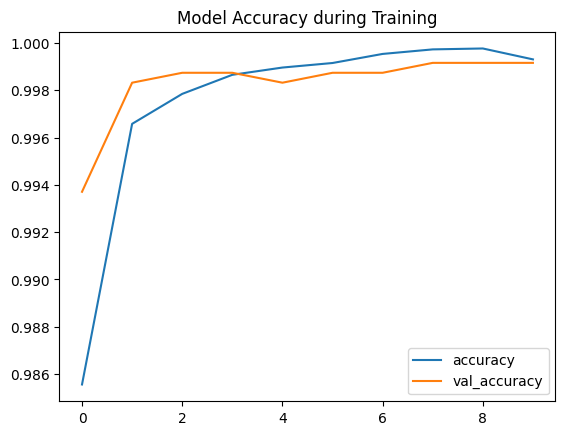

In [39]:
losses[['accuracy','val_accuracy']].plot()
plt.title('Model Accuracy during Training')

Text(0.5, 1.0, 'Model Loss during Training')

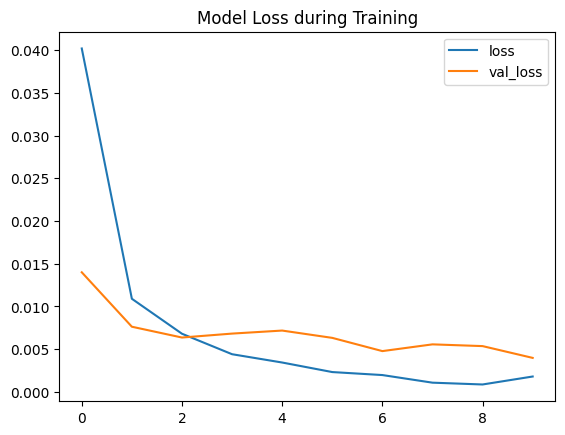

In [40]:
losses[['loss','val_loss']].plot()
plt.title('Model Loss during Training')

In [41]:
val_loss, val_accuracy=model.evaluate(val_data.dataset)
print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_accuracy:.4f}")

75/75 ━━━━━━━━━━━━━━━━━━━━ 67s 885ms/step - accuracy: 0.9991 - loss: 0.0038
Validation Loss: 0.0040
Validation Accuracy: 0.9992


In [42]:
test_data = TFDataset(
    test_df,
    augment=False,
    batch_size=BATCH_SIZE,
    shuffle=False,
    image_size=image_size,
)

In [43]:
print("Number of samples:", len(test_data.df))
print("Number of batches:", len(test_data))

Number of samples: 1022
Number of batches: 32


In [44]:
y_true = np.concatenate( [y for _, y in val_data.dataset],
    axis=0
)

y_prob = model.predict(val_data.dataset).ravel()

y_pred = (y_prob >= 0.5).astype(int)

print(classification_report(y_true, y_pred))

75/75 ━━━━━━━━━━━━━━━━━━━━ 80s 930ms/step
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00       840
         1.0       1.00      1.00      1.00      1543

    accuracy                           1.00      2383
   macro avg       1.00      1.00      1.00      2383
weighted avg       1.00      1.00      1.00      2383



In [45]:
y_true = np.concatenate( [y for _, y in test_data.dataset],
    axis=0
)

y_prob = model.predict(test_data.dataset).ravel()

y_pred = (y_prob >= 0.5).astype(int)

print(classification_report(y_true, y_pred))

32/32 ━━━━━━━━━━━━━━━━━━━━ 37s 1s/step 
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00       360
         1.0       1.00      1.00      1.00       662

    accuracy                           1.00      1022
   macro avg       1.00      1.00      1.00      1022
weighted avg       1.00      1.00      1.00      1022



In [48]:
report = classification_report(y_true, y_pred, output_dict=True)
df_report = pd.DataFrame(report).transpose()
df_report

,precision,recall,f1-score,support
0.0,0.997230,1.000000,0.998613,360.000000
1.0,1.000000,0.998489,0.999244,662.000000
accuracy,0.999022,0.999022,0.999022,0.999022
macro avg,0.998615,0.999245,0.998929,1022.000000
weighted avg,0.999024,0.999022,0.999022,1022.000000


In [47]:
print("Overall precision:", report["weighted avg"]["precision"])
print("Overall recall:", report["weighted avg"]["recall"])
print("Overall f1-score:", report["weighted avg"]["f1-score"])
print("Overall accuracy:",report["accuracy"])

Overall precision: 0.9990242368719203
Overall recall: 0.9990215264187867
Overall f1-score: 0.9990218351784018
Overall accuracy: 0.9990215264187867


### Validate on unseen samples

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step


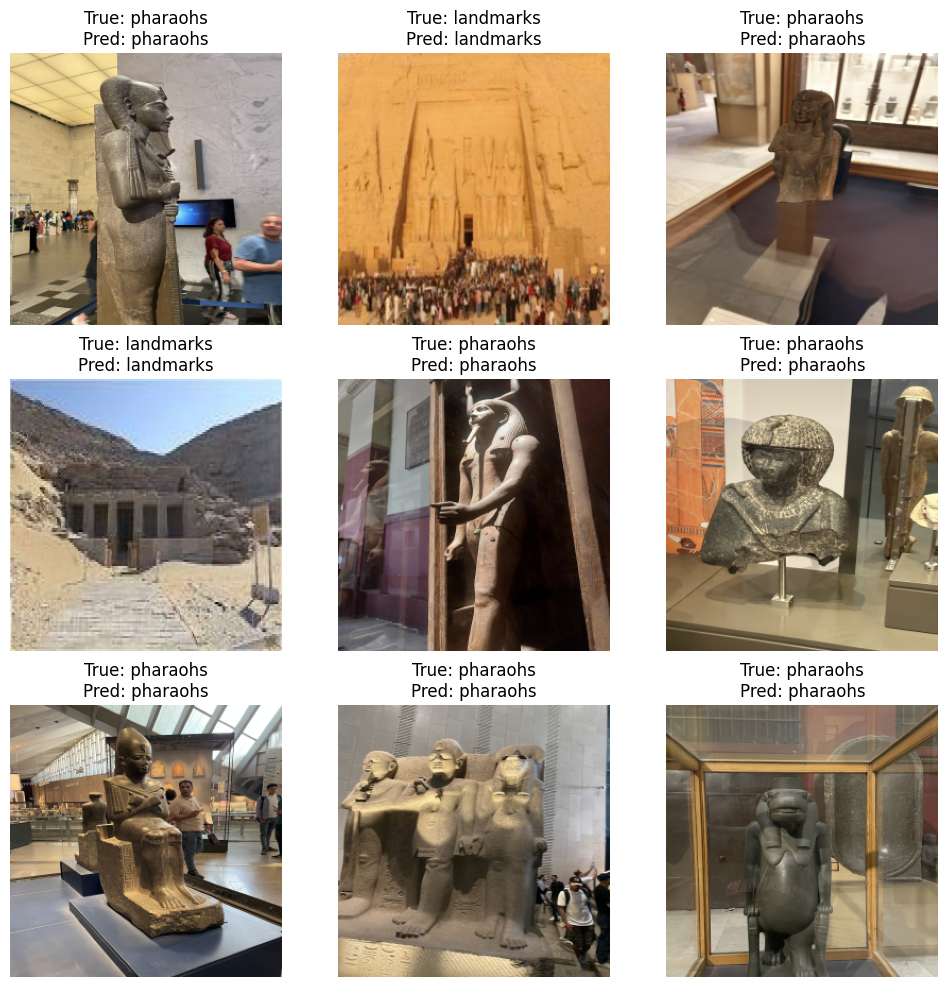

In [49]:
#Displays orignal image, passes the preprocessed test data to the model which already has preprocess_input in inputs(normalize[0,1] to [-1,1]).
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

def display_batch_binary(dataset, encoder=None, n=9, threshold=0.5):
    batch = dataset.dataset.shuffle(buffer_size=1000).take(1)
    for images, labels in batch:
        preds_prob = model.predict(images)
        preds_classes = (preds_prob >= threshold).astype(int).ravel()
        break

    plt.figure(figsize=(12, 12))
    for i in range(n):
        plt.subplot(3, 3, i + 1)
        img = images[i].numpy()

        if img.max() > 1.0: #matplot lib expects images to be [0-1] or [0-255 uint(ours is float)],images here have not gone through normalization of [0,1], thats why we normalize to display
            img = img / 255.0
    
        plt.imshow(np.clip(img, 0, 1))

        # map true/pred labels through encoder if provided
        if encoder:
            true_label = encoder.inverse_transform([int(labels[i].numpy())])[0]
            pred_label = encoder.inverse_transform([preds_classes[i]])[0]
        else:
            true_label = int(labels[i].numpy())
            pred_label = int(preds_classes[i])

        plt.title(f"True: {true_label}\nPred: {pred_label}")
        plt.axis("off")
    plt.show()

# Example usage:
display_batch_binary(test_data, encoder=encoder, n=9)


In [50]:
import pickle
model.save('/kaggle/working/Mobilenet V2 Binary.keras')

encoder_file = "label_encoder.pkl"

with open(encoder_file, "wb") as f:
    pickle.dump(encoder, f)

In [6]:
import pickle

model = load_model(
    r"C:\Uni\4th Year\GP\Implementation\Recognition\Landmarks\Inception V3 -AUG\Inception V3.keras")

with open(r"C:\Uni\4th Year\GP\Implementation\Recognition\Landmarks\Inception V3 -AUG\label_encoder.pkl", "rb") as f:
    encoder = pickle.load(f)

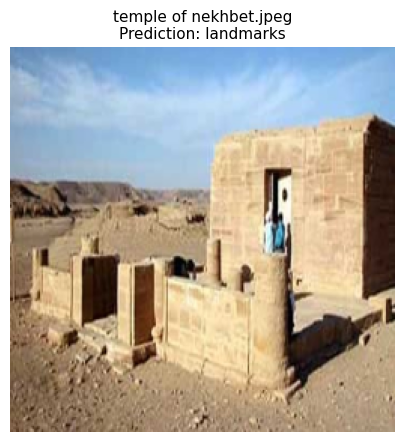

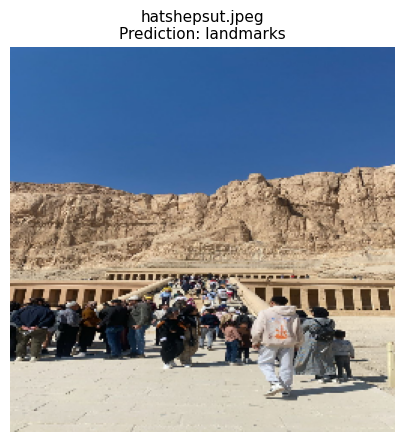

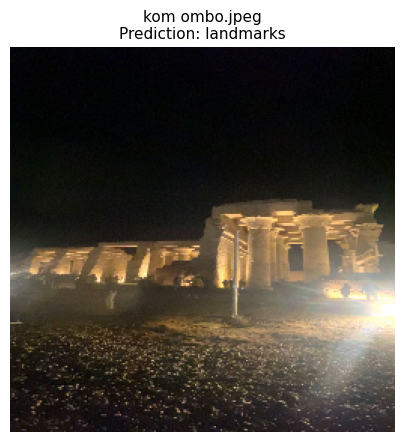

In [51]:
TEST_FOLDER = r"/kaggle/input/test-sample"
IMAGE_SIZE = 256
MAX_IMAGES = 12

image_files = [f for f in os.listdir(TEST_FOLDER) if f.lower().endswith((".jpg", ".jpeg", ".png"))][:MAX_IMAGES]

for img_file in image_files:
    img_path = os.path.join(TEST_FOLDER, img_file)

    img_bgr = cv2.imread(img_path)
    if img_bgr is None:
        print(f"Could not read {img_path}")
        continue

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (IMAGE_SIZE, IMAGE_SIZE)) # Resize to model input size
    #no normalize form 255 to 1 since model was trained on 0-255 images(what inception expects)
    x = np.expand_dims(img_resized, axis=0) 
    pred = model.predict(x, verbose=0) # already exists pre_process_input
    preds_classes = (pred >= 0.5).astype(int).ravel()
    pred_label = encoder.inverse_transform([preds_classes])[0]


    plt.figure(figsize=(5, 5))
    plt.imshow(img_resized)
    plt.title(f"{img_file}\nPrediction: {pred_label}", fontsize=11)
    plt.axis("off")
    plt.show()